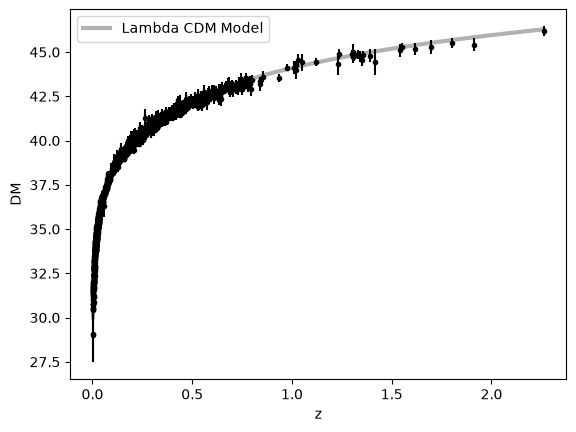

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad
from classy import Class

columns = ['zCMB', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']
df = pd.read_csv('/mnt/c/Users/HP/Downloads/CTP/Cosmology project/Pantheon+SH0ES.dat', sep=r'\s+', usecols=columns, comment='#')
z = df['zCMB'].values                # Redshift
y = df['MU_SH0ES'].values            # Distance Modulus
yerr = df['MU_SH0ES_ERR_DIAG'].values # Error bars



DESI = pd.read_csv('/mnt/c/Users/HP/Downloads/CTP/Cosmology project/desi_gaussian_bao_ALL_GCcomb_mean.txt', sep=r'\s+', comment='#', 
                     names=['z', 'value', 'type'])

cov_matrix = np.loadtxt('/mnt/c/Users/HP/Downloads/CTP/Cosmology project/desi_gaussian_bao_ALL_GCcomb_cov.txt')
inv_cov = np.linalg.inv(cov_matrix)



def H_LCDM(z, H0, Om):
    H = H0 * np.sqrt(Om*(1+z)**3 + (1-Om))
    return H    

def comoving_distance(z, H0, Om, c=299792.458, *args):
    E_func = lambda z_prime: np.sqrt(Om * (1 + z_prime)**3 + (1 - Om))
    integral = quad (lambda z_prime: 1.0 / E_func(z_prime, *args), 0, z)[0]
    D_H = c / H0
    D_C = D_H * integral
    return D_C


def Luminosity_distance(z, H0, Om, c=299792.458):
    D_L = (1 + z) * comoving_distance(z, H0, Om, c)
    return D_L


def Distance_modulus(z, H0, Om):
    D_L = Luminosity_distance(z, H0, Om, c=299792.458) 
    D_M = 5 * np.log10(D_L) + 25 #Distance Modulus in Mpc
    return D_M

def calc_rd(H0, Om):

    h = H0 / 100.0
    omega_b = 0.0224 
    omega_m = Om * h**2
    rd = 55.154 / (omega_m**0.25351 * omega_b**0.12807)
    return rd

z0 = np.linspace(0.01, np.max(z), len(z))
H_model = H_LCDM
params = (70.0, 0.3)
y_model = np.array([Distance_modulus(zi, *params) for zi in z0])

plt.errorbar(z, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(z0, y_model, "k", alpha=0.3, lw=3, label="Lambda CDM Model")
plt.xlabel("z")
plt.ylabel("DM")
plt.legend()
plt.show()

In [35]:
from scipy.optimize import minimize

def log_likelihood_PAN(theta, z, y, yerr):
    H0, Om = theta
    model = np.array([Distance_modulus(zi, H0, Om) for zi in z])
    sigma2 = yerr**2 
    return -0.5 * np.sum((y - model) ** 2 / sigma2)

def log_likelihood_DESI(theta, desi_df, inv_cov, c=299792.458): 
    H0, Om = theta
    rd = calc_rd(H0, Om)
    
    model_vals = []
    
    for index, row in desi_df.iterrows():
        z = row['z']
        
        obs_type = str(row['type']).strip() 
        
        DC = comoving_distance(z, H0, Om)
        DM = DC 
        DH = c / H_LCDM(z, H0, Om)
        DV = (z * DM**2 * DH)**(1.0 / 3.0)
        
        if obs_type == 'DM_over_rs':
            model_vals.append(DM / rd)
        elif obs_type == 'DH_over_rs':
            model_vals.append(DH / rd)
        elif obs_type == 'DV_over_rs':
            model_vals.append(DV / rd)
            
    model_array = np.array(model_vals)
    obs_array = desi_df['value'].values
    
    delta = obs_array - model_array
    
    chi2 = np.dot(delta.T, np.dot(inv_cov, delta))
    
    return -0.5 * chi2

def joint_log_likelihood(theta, z_pan, y_pan, yerr_pan, DESI, inv_cov):
    H0, Om = theta
    
    if not (50.0 < H0 < 100.0 and 0.05 < Om < 0.95):
        return -np.inf
        
    ll_pan = log_likelihood_PAN(theta, z_pan, y_pan, yerr_pan)
    ll_desi = log_likelihood_DESI(theta, DESI, inv_cov)
    
    return ll_pan + ll_desi

nll_joint = lambda theta: -joint_log_likelihood(theta, z, y, yerr, DESI, inv_cov)

np.random.seed(42)
initial = np.array([70.0, 0.3]) + 0.1 * np.random.randn(2)
bnds = ((50, 100), (0.05, 0.95))

soln = minimize(nll_joint, initial, bounds=bnds, method='Nelder-Mead')
H0_ml, Om_ml = soln.x

print("=== Joint Fit Results (Pantheon+ & DESI BAO) ===")
print(f"H0 = {H0_ml:.3f} km/s/Mpc")
print(f"Om = {Om_ml:.3f}")

=== Joint Fit Results (Pantheon+ & DESI BAO) ===
H0 = 72.315 km/s/Mpc
Om = 0.338


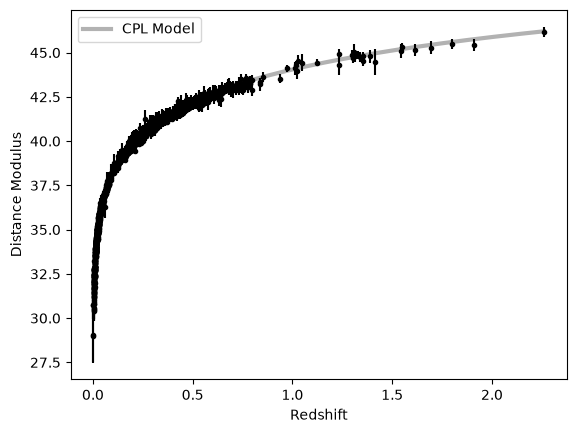

In [36]:
## CPL using classy

Model_CPL = Class() 
Model_CPL.set({  
    'omega_b': 0.02238,
    'omega_cdm': 0.12011,
    'H0': 67.5,
    'Omega_Lambda': 0.0,          
    'w0_fld': -0.8,            
    'wa_fld': 0.3,             
    'cs2_fld': 1.0,              
})

Model_CPL.compute()

def H_CPL(z, H0, Om, w0, wa):
    H = H0 * np.sqrt(Om*(1+z)**3 + (1-Om)*(1+z)**(3*(1+w0+wa)) * np.exp(-3*wa*z/(1+z)))
    return H

def Distance_modulus_CPL(z):
    D_L = Model_CPL.luminosity_distance(z) 
    D_M = 5 * np.log10(D_L) + 25 #Distance Modulus in Mpc
    return D_M


z0 = np.linspace(0.01, np.max(z), len(z))
H_model = H_CPL
CPL_model = np.array([Distance_modulus_CPL(zi) for zi in z0])

plt.errorbar(z, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(z0, CPL_model, "k", alpha=0.3, lw=3, label= "CPL Model")
plt.xlabel('Redshift')
plt.ylabel('Distance Modulus')
plt.legend()
plt.show()


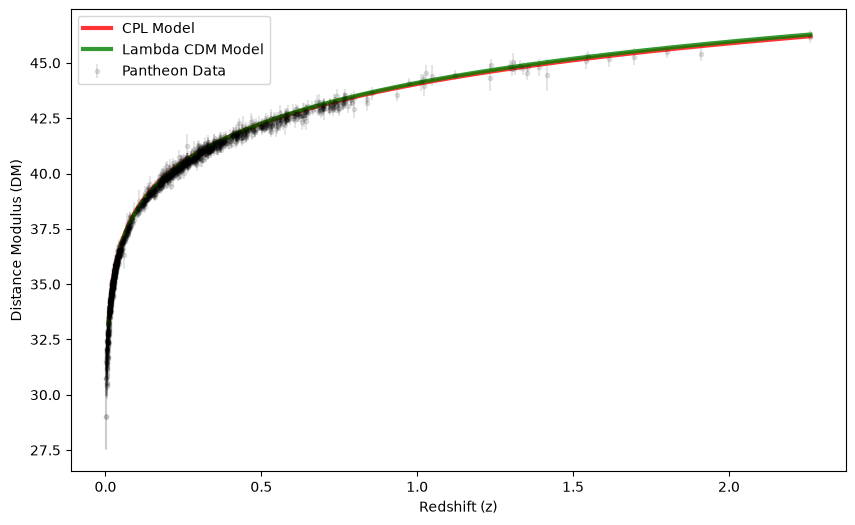

In [37]:
plt.figure(figsize=(10, 6))

plt.errorbar(z, y, yerr=yerr, fmt=".k", capsize=0, alpha=0.1, label="Pantheon Data")

plt.plot(z0, CPL_model, "r", alpha=0.8, lw=3, label="CPL Model")

plt.plot(z0, y_model, "g", alpha=0.8, lw=3, label="Lambda CDM Model")


plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (DM)")
plt.legend()
plt.show()

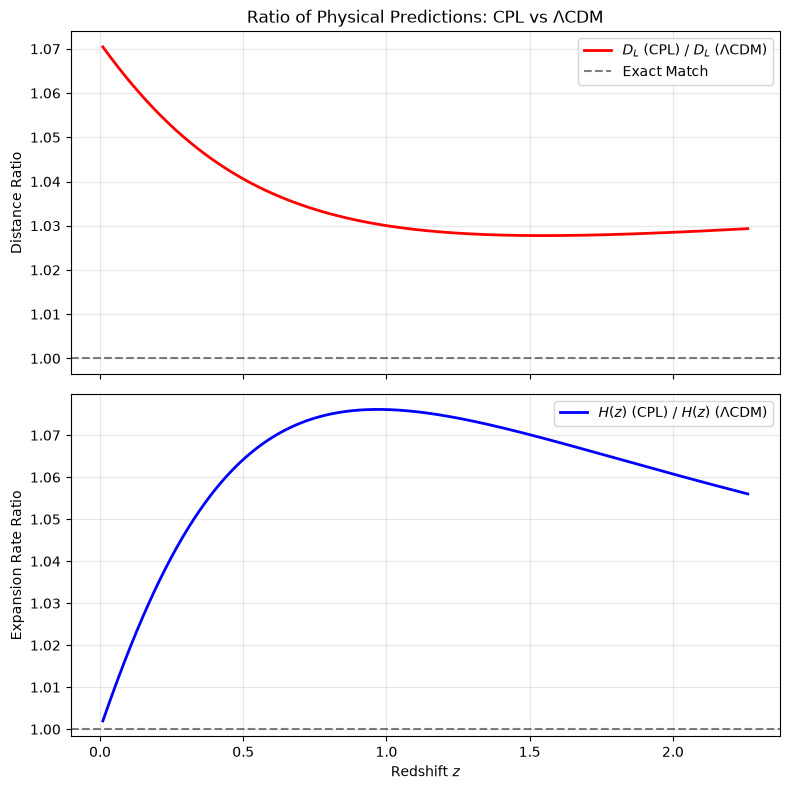

In [ ]:
#The ratio between lambda cdm and cpl
DL_LCDM = np.array([Luminosity_distance(zi, H0_ml, Om_ml) for zi in z0])
DL_CPL = np.array([Model_CPL.luminosity_distance(zi) for zi in z0])

DL_ratio = DL_CPL / DL_LCDM

H_LCDM_vals = np.array([H_LCDM(zi, H0_ml, Om_ml) for zi in z0])
H_CPL_vals = np.array([H_CPL(zi, H0_ml, Om_ml, w0=-0.8, wa=0.3) for zi in z0])

H_ratio = H_CPL_vals / H_LCDM_vals

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Top Panel: Luminosity Distance Ratio
ax1.plot(z0, DL_ratio, "r-", lw=2, label=r'$D_L$ (CPL) / $D_L$ ($\Lambda$CDM)')
ax1.axhline(1.0, color='k', linestyle='--', alpha=0.5, label="Exact Match")
ax1.set_ylabel('Distance Ratio')
ax1.set_title(r'Ratio of Physical Predictions: CPL vs $\Lambda$CDM')
ax1.legend()
ax1.grid(alpha=0.3)

# Bottom Panel: Hubble Parameter Ratio
ax2.plot(z0, H_ratio, "b-", lw=2, label=r'$H(z)$ (CPL) / $H(z)$ ($\Lambda$CDM)')
ax2.axhline(1.0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Redshift $z$')
ax2.set_ylabel('Expansion Rate Ratio')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

